# Advanced Document Restoration for OCR


## Install libraries

In [1]:
!pip install datasets opencv-python pytesseract scikit-image pandas matplotlib tqdm -q
!pip install -U datasets huggingface_hub


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


## Import libraries

In [2]:
import cv2
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract

from tqdm import tqdm
from datasets import load_dataset
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

## Dataset Loading
### 70/30 Train-Test Split

In [4]:

data = load_dataset("Voxel51/form_understanding_in_noisy_scanned_documents_plus")

dataSplit = data["train"].train_test_split(
    test_size=0.30,
    seed=42
)

train = dataSplit["train"]
test = dataSplit["test"]

Resolving data files:   0%|          | 0/1026 [00:00<?, ?it/s]

## Image Preprocessing

- Convert the image to grayscale.
- Resize the image by 2× using bicubic interpolation.
- Apply CLAHE to enhance local contrast.
- Use median filtering to reduce noise while preserving text details.


In [5]:
def grayImage(img):
    img = np.array(img)

    # Convert to grayscale
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Invert if image is dark
    if np.mean(img) < 127:
        img = cv2.bitwise_not(img)

    return img.astype(np.uint8)


def processImage(gray):
    # Copy image
    image = gray.copy().astype(np.uint8)

    # Resize image
    image = cv2.resize(
        image,
        None,
        fx=2,
        fy=2,
        interpolation=cv2.INTER_CUBIC
    )

    # Improve contrast
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    image = clahe.apply(image)

    # Remove noise
    image = cv2.medianBlur(image, 3)

    return image

## OCR Evaluation

Tesseract OCR is used to extract text and confidence scores from each image. Empty detections and invalid confidence values are removed. The evaluation is based on:

- Average OCR confidence
- Number of detected words

These metrics help assess the impact of preprocessing on text recognition performance.

In [6]:
def ocrScore(img):
    # Run OCR and get detailed results
    try:
        data = pytesseract.image_to_data(
            img,
            output_type=pytesseract.Output.DICT,
            config="--psm 6 --oem 3 -c tessedit_do_invert=0",
            timeout=20
        )
    except RuntimeError:
        return 0, 0

    confs = []
    words = []

    # Collect valid words and confidence scores
    for conf, text in zip(data["conf"], data["text"]):
        text = text.strip()

        if text != "":
            try:
                conf = float(conf)

                if conf > 0:
                    confs.append(conf)
                    words.append(text)

            except:
                pass

    # Calculate average confidence
    avgConf = np.mean(confs) if len(confs) > 0 else 0

    # Count detected words
    wordCount = len(words)

    return avgConf, wordCount

## Image Quality Evaluation

The processed image is resized to match the original image size before evaluation. Image quality is measured using:

- **PSNR:** Evaluates image distortion.
- **SSIM:** Measures structural similarity between images.

These metrics are used to assess the effect of preprocessing on image quality.

In [7]:
def imageQuality(before, after):

    # Resize processed image to original size
    afterSmall = cv2.resize(
        after,
        (before.shape[1], before.shape[0])
    )

    # Calculate PSNR
    psnrValue = peak_signal_noise_ratio(
        before,
        afterSmall,
        data_range=255
    )

    # Calculate SSIM
    ssimValue = structural_similarity(
        before,
        afterSmall,
        data_range=255
    )

    return psnrValue, ssimValue

## Percentage Change Calculation

Percentage change is used to measure the improvement between the original and processed results after preprocessing.

In [8]:
def change(before, after):

    # Check for zero value
    if before == 0:
        return 0

    # Find change percentage
    return ((after - before) / before) * 100

## Training Set Quality Assessment

The preprocessing pipeline is evaluated on the training set using:

- Average PSNR
- Average SSIM
- Average processing time

These metrics measure image quality preservation and computational efficiency.

In [9]:
# Store quality metrics
trainPsnr = []
trainSsim = []
trainTime = []

# Process training images
for i in tqdm(range(len(train)), desc="Training Set"):
    before = grayImage(train[i]["image"])

    start = time.time()

    after = processImage(before)

    trainTime.append(time.time() - start)

    # Measure image quality
    psnrValue, ssimValue = imageQuality(
        before,
        after
    )

    trainPsnr.append(psnrValue)
    trainSsim.append(ssimValue)

# Create summary table
trainQuality = pd.DataFrame({
    "Set": ["Training Set"],
    "PSNR": [np.mean(trainPsnr)],
    "SSIM": [np.mean(trainSsim)],
    "Processing Time (s)": [np.mean(trainTime)]
})

trainQuality

Training Set: 100%|███████████████████████████████████████████████████████████████████| 718/718 [01:40<00:00,  7.15it/s]


,Set,PSNR,SSIM,Processing Time (s)
0,Training Set,30.317372,0.987824,0.010866


## Testing Set Evaluation

The testing set is used to assess the effectiveness of the preprocessing pipeline.

*  OCR confidence
*  Detected word count
*   PSNR
*   processing time

across all test images. Percentage improvements in OCR confidence and detected words are calculated to evaluate the impact of preprocessing.

In [10]:
!pip install pytesseract -q
import pytesseract

print("Tesseract Ready")


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Tesseract Ready


In [11]:
# Store OCR and quality metrics
beforeConf = []
afterConf = []
beforeWords = []
afterWords = []
testPsnr = []
testSsim = []
testTime = []

# Process testing images
for i in tqdm(range(len(test)), desc="Testing Set"):

    before = grayImage(test[i]["image"])

    # OCR before processing
    bConf, bWords = ocrScore(before)

    start = time.time()

    after = processImage(before)

    testTime.append(time.time() - start)

    # OCR after processing
    aConf, aWords = ocrScore(after)

    # Measure image quality
    psnrValue, ssimValue = imageQuality(before, after)

    beforeConf.append(bConf)
    afterConf.append(aConf)
    beforeWords.append(bWords)
    afterWords.append(aWords)
    testPsnr.append(psnrValue)
    testSsim.append(ssimValue)

# Create summary table
testSummary = pd.DataFrame({
    "Metric": [
        "OCR Confidence",
        "Detected Words",
        "PSNR",
        "SSIM",
        "Processing Time (s)"
    ],
    "Before": [
        np.mean(beforeConf),
        np.mean(beforeWords),
        "-",
        "-",
        "-"
    ],
    "After": [
        np.mean(afterConf),
        np.mean(afterWords),
        np.mean(testPsnr),
        np.mean(testSsim),
        np.mean(testTime)
    ],
    "Change (%)": [
        change(np.mean(beforeConf), np.mean(afterConf)),
        change(np.mean(beforeWords), np.mean(afterWords)),
        "-",
        "-",
        "-"
    ]
})

testSummary

Testing Set: 100%|████████████████████████████████████████████████████████████████████| 308/308 [05:37<00:00,  1.10s/it]


,Metric,Before,After,Change (%)
0,OCR Confidence,62.00416,63.754167,2.822403
1,Detected Words,159.019481,164.480519,3.434195
2,PSNR,-,30.454735,-
3,SSIM,-,0.988352,-
4,Processing Time (s),-,0.009976,-


## Training and Testing Set Comparison

This section summarizes the average PSNR, SSIM, and processing time for both the training and testing sets. The results provide an overall assessment of preprocessing quality and consistency across different data splits.

In [12]:
# Combine training and testing results
qualitySummary = pd.DataFrame({
    "Set": ["Training Set", "Testing Set"],
    "PSNR": [
        np.mean(trainPsnr),
        np.mean(testPsnr)
    ],
    "SSIM": [
        np.mean(trainSsim),
        np.mean(testSsim)
    ],
    "Processing Time (s)": [
        np.mean(trainTime),
        np.mean(testTime)
    ]
})

# Round values
qualitySummary = qualitySummary.round(4)

qualitySummary

,Set,PSNR,SSIM,Processing Time (s)
0,Training Set,30.3174,0.9878,0.0109
1,Testing Set,30.4547,0.9884,0.0100


## OCR Performance Summary

This table summarizes the average OCR performance before and after preprocessing. The results compare OCR confidence and the number of detected words, along with the percentage change for each metric to quantify the impact of the preprocessing pipeline.

In [13]:
# Build a summary table for the main OCR results
ocrTable = pd.DataFrame({
    "Metric": [
        "OCR confidence",
        "Detected words"
    ],
    "Before": [
        np.mean(beforeConf),
        np.mean(beforeWords)
    ],
    "After": [
        np.mean(afterConf),
        np.mean(afterWords)
    ],
    "Change (%)": [
        change(
            np.mean(beforeConf),
            np.mean(afterConf)
        ),
        change(
            np.mean(beforeWords),
            np.mean(afterWords)
        )
    ]
})

# Round values to make the table easier to read
ocrTable = ocrTable.round(2)

ocrTable

,Metric,Before,After,Change (%)
0,OCR confidence,62.00,63.75,2.82
1,Detected words,159.02,164.48,3.43


## OCR Results Visualization

This chart compares OCR performance before and after preprocessing using average confidence scores and detected word counts.

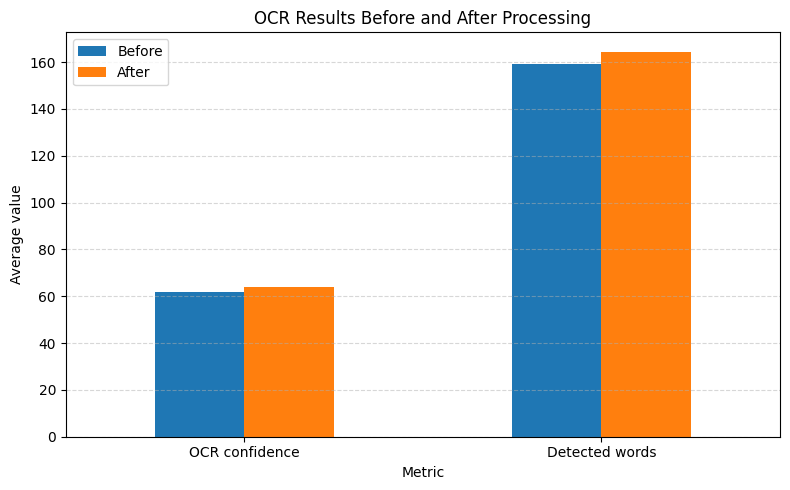

In [14]:
# Compare OCR results before and after processing
ocrTable.plot(
    x="Metric",
    y=["Before", "After"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("OCR Results Before and After Processing")
plt.ylabel("Average value")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.tight_layout()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

## Before and After Image Comparison

Ten test images are displayed before and after preprocessing to visually assess the impact of the enhancement pipeline on image quality and text readability.

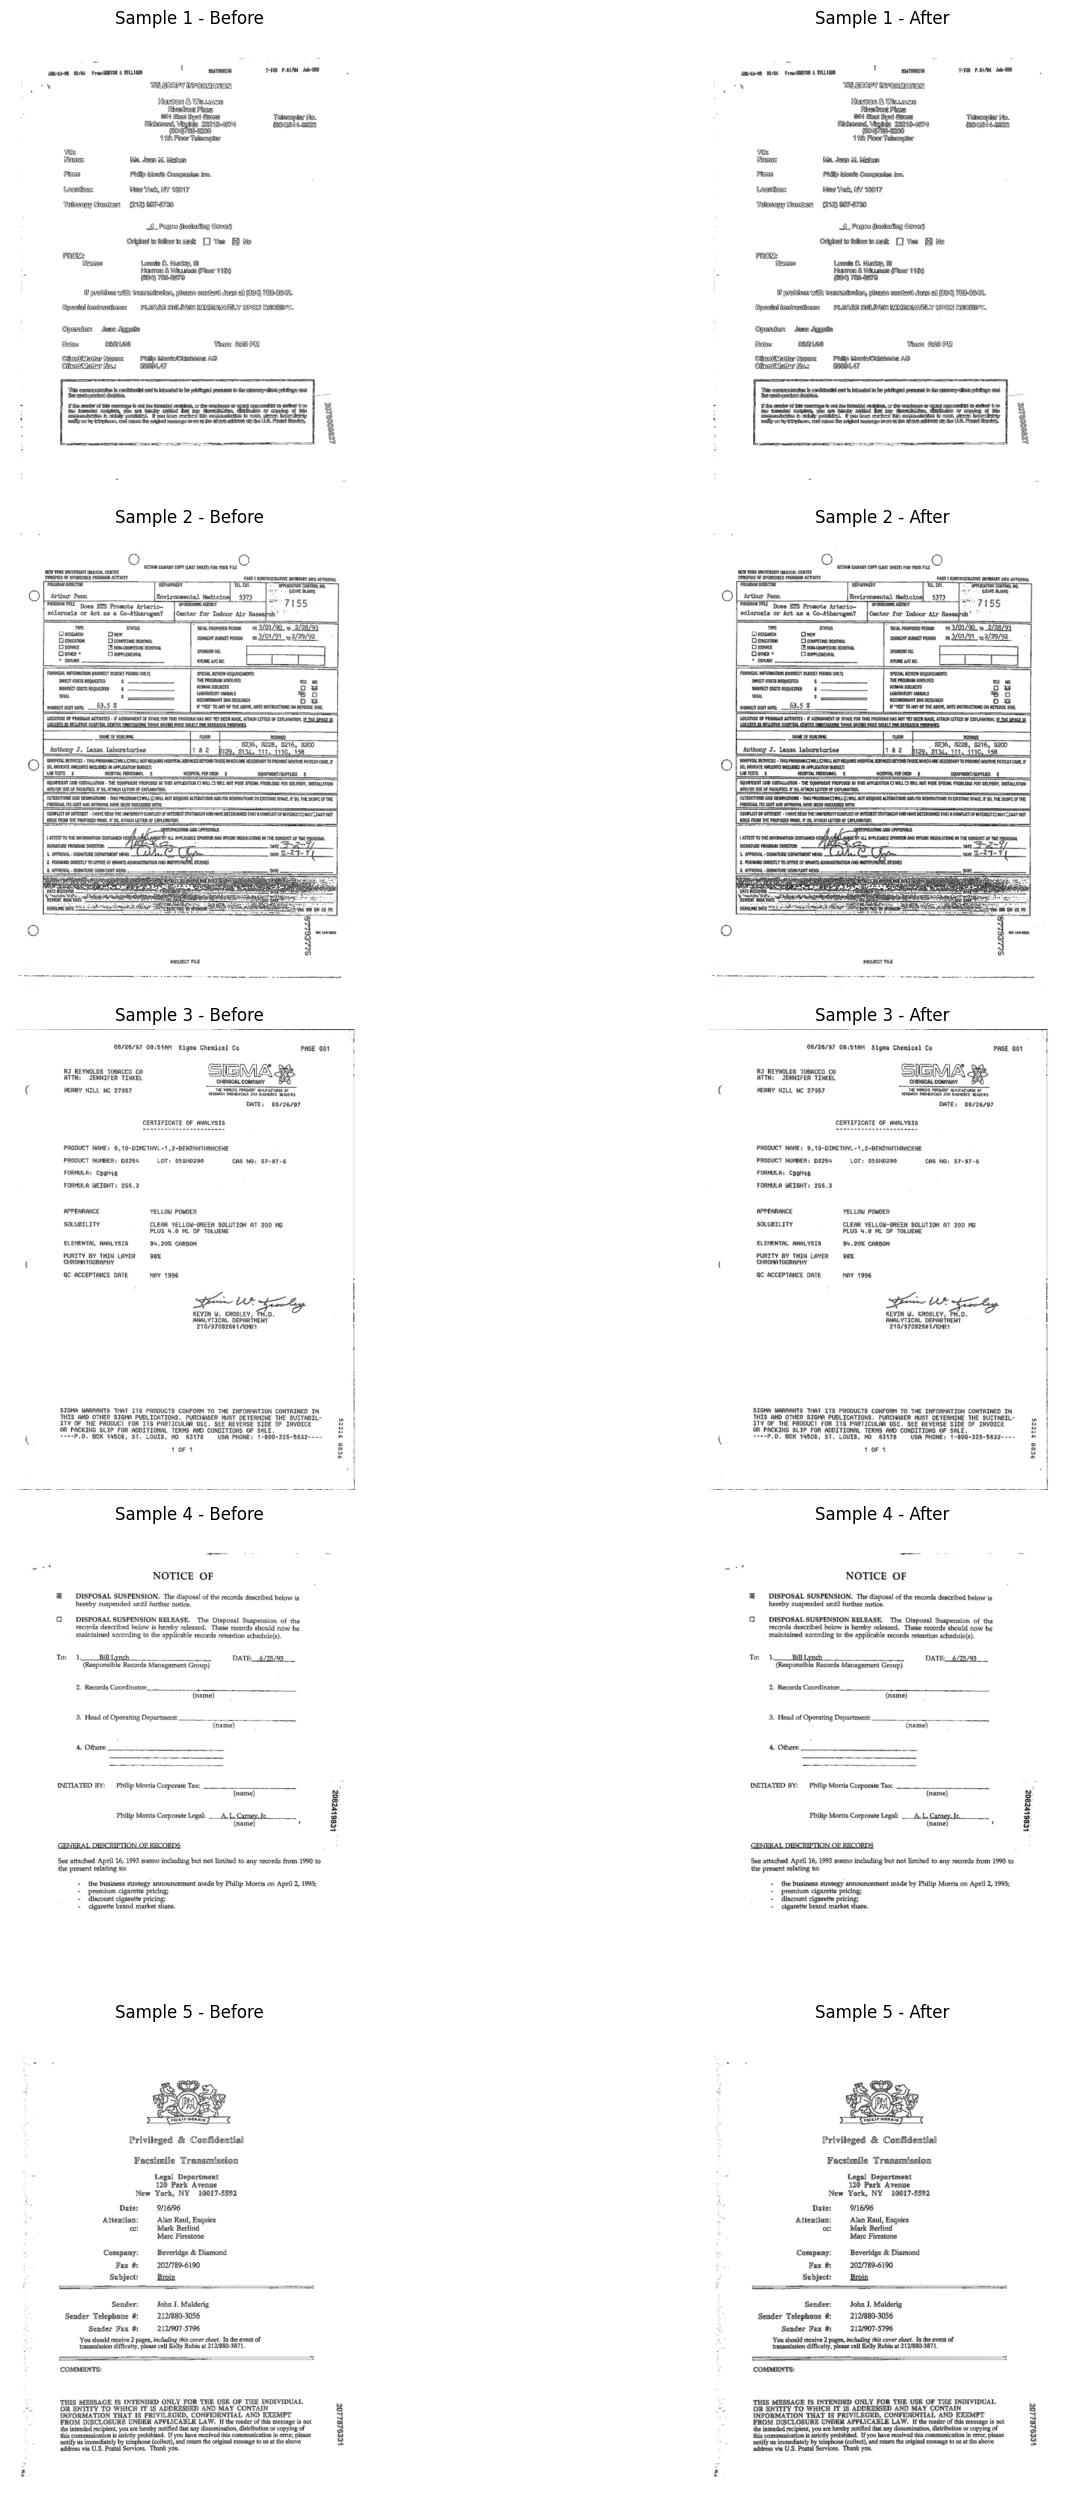

In [15]:
# Select 5 test samples with equal spacing
sampleIds = np.random.choice(
    len(test),
    5,
    replace=False
)

plt.figure(figsize=(14, 50))

for row, i in enumerate(sampleIds):

    # Prepare the original and processed images
    before = grayImage(
        test[int(i)]["image"]
    )

    after = processImage(
        before
    )

    # Show the image before processing
    plt.subplot(10, 2, row * 2 + 1)
    plt.imshow(before, cmap="gray")
    plt.title(f"Sample {row + 1} - Before")
    plt.axis("off")

    # Show the image after processing
    plt.subplot(10, 2, row * 2 + 2)
    plt.imshow(after, cmap="gray")
    plt.title(f"Sample {row + 1} - After")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Select 5 samples to compare OCR scores
sampleIds = np.linspace(
    0,
    len(test) - 1,
    5,
    dtype=int
)

sampleResults = []

for sampleNumber, i in enumerate(sampleIds):

    before = grayImage(test[int(i)]["image"])
    after = processImage(before)

    # Calculate OCR scores before and after processing
    beforeConfValue, beforeWordsValue = ocrScore(before)
    afterConfValue, afterWordsValue = ocrScore(after)

    # Store the sample result in one row
    sampleResults.append({
        "Sample": sampleNumber + 1,
        "Before confidence": beforeConfValue,
        "After confidence": afterConfValue,
        "Confidence change": afterConfValue - beforeConfValue,
        "Before words": beforeWordsValue,
        "After words": afterWordsValue,
        "Word change": afterWordsValue - beforeWordsValue
    })

# Display sample scores in a clean table
sampleResults = pd.DataFrame(sampleResults)
sampleResults = sampleResults.round(2)

sampleResults

,Sample,Before confidence,After confidence,Confidence change,Before words,After words,Word change
0,1,42.56,41.47,-1.09,98,127,29
1,2,47.62,54.22,6.60,140,160,20
2,3,62.44,64.59,2.15,255,260,5
3,4,81.35,82.76,1.41,410,404,-6
4,5,42.80,42.92,0.12,118,140,22


## OCR Results on Sample Images

The following examples show OCR results before and after preprocessing. Confidence scores and detected word counts are included to assess the improvement in text extraction.

In [17]:
sampleIds = np.linspace(
    42,
    len(test) - 1,
    5,
    dtype=int
)

# Extract text from image
def extractText(img):
    return pytesseract.image_to_string(
        img,
        config="--psm 6 --oem 3"
    )

# Show OCR results for selected samples
for sampleNumber, i in enumerate(sampleIds, start=1):

    before = grayImage(test[int(i)]["image"])
    after = processImage(before)

    # Extract text before and after
    beforeText = extractText(before)
    afterText = extractText(after)

    # Get OCR scores
    sBeforeConf, sBeforeWords = ocrScore(before)
    sAfterConf, sAfterWords = ocrScore(after)

    print("=" * 120)
    print(f"SAMPLE {sampleNumber}")
    print("=" * 120)

    print(f"\nBefore OCR | Confidence: {sBeforeConf:.2f} | Words: {sBeforeWords}\n")
    print(beforeText)

    print("\n" + "-" * 120)

    print(f"\nAfter OCR | Confidence: {sAfterConf:.2f} | Words: {sAfterWords}\n")
    print(afterText)

    print("\n\n")

SAMPLE 1

Before OCR | Confidence: 64.23 | Words: 288

‘
v |
uo @ R. J. REYWOLDS TOBACCO USA !
ee.” Prototype Development Request |
* secaer |
i
Project 86 Reference Humber, 87-3,
wa. Product Leprovement: Originated By:
-X_ New Product Introduction
ww Brand Line Extension Heme: _ Howard 3. Porke
Department: Marker sng
Development Priority:
KR Intefol Request
Change/Previous Reference No.

1, OBJECTIVE: Project SG is being developed as @ sub-generic priced brand which would
be introduced to counter/defend @ competitor's entry at this lower price ties. Sivan
the financial objectives of thie proposition, the product development objective te |
to develop the lowest cost of goods product with “acceptable” taste.

TR, RATIONALE: Given the prices ef clgsrettes and the intensive competition in the
cigarette industry, a competitor mey decide te introduce a gub-generic product as
early ag First Quarter 1988, Thie introduction would place RIRT in a vulnerable |
position, Therefore, RINT must be r